# 02 — H1 Results: Agenda Distortion Metrics

Computes all H1 metrics for each outlet vs Tagesschau (mainstream reference).

**Metrics** (all size-controlled or rank-based):

| Metric | What | Literature |
|--------|------|------------|
| Normalized entropy | Topic concentration | Boydstun et al. (2014) |
| JSD | Agenda divergence | DiMaggio et al. (2013) |
| Spearman ρ | Topic priority agreement | McCombs & Shaw (1972) |
| Top-K overlap | Shared top topics | Heidenreich et al. (2019) |
| Coverage breadth (rel.) | Topic range vs expected | Size-controlled binomial model |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("No .git found")

PROJECT_ROOT = find_project_root(Path.cwd())
EXPERIMENT_DIR = PROJECT_ROOT / "experiments" / "agenda_distortion"
OUTPUT_DIR = EXPERIMENT_DIR / "outputs"

for p in [str(EXPERIMENT_DIR), str(PROJECT_ROOT / "1a_BERTopic")]:
    if p not in sys.path:
        sys.path.insert(0, p)

print(f"Loading from: {OUTPUT_DIR}")

Loading from: /Users/MattisHaumann/Dev/Thesis/experiments/agenda_distortion/outputs


## Load Iteration Data

In [2]:
from modeling import load_iteration

ITERATION_ID = "v1"  # must match notebook 01

result = load_iteration(OUTPUT_DIR, ITERATION_ID)
merged_articles = result.merged_articles
merged_topic_info = result.merged_topic_info

print(f"Loaded iteration '{ITERATION_ID}': {len(merged_articles):,} articles, {result.n_topics} topics")

Loaded iteration 'v1': 20,455 articles, 74 topics


/Users/MattisHaumann/Dev/Thesis/experiments/agenda_distortion/modeling.py:405: DtypeWarning: Columns (0: tags, 1: content, 2: topline, 3: ressort, 4: type, 5: Category, 6: Summary, 7: Full_Text, 8: Author, 9: Inhalt) have mixed types. Specify dtype option on import or set low_memory=False.
  merged_articles = pd.read_csv(iter_dir / "merged_articles.csv")


## H1 Metrics — Per Outlet

In [3]:
from metrics import compute_all_h1_metrics, format_metrics_table, classify_distortion

metrics_df = compute_all_h1_metrics(merged_articles, top_k=10, min_articles=10)

print("H1 Metrics — All Outlets vs Tagesschau")
print("=" * 80)
display(format_metrics_table(metrics_df))

# Save for thesis
metrics_df.to_csv(OUTPUT_DIR / ITERATION_ID / "h1_metrics.csv", index=False)

H1 Metrics — All Outlets vs Tagesschau


,Outlet,Articles,Entropy,JSD,Spearman ρ,Top-K Overlap,Breadth (rel.),Size
0,Antispiegel,565,0.7336,0.3977,0.3468,0.4,0.6568,SMALL
1,Compact,1580,0.8781,0.2134,0.2528,0.5,0.7804,OK
2,Deutschlandkurier,1460,0.8451,0.2188,0.4371,0.4,0.7436,OK
3,Nius,3266,0.8805,0.1920,0.3082,0.4,0.8385,OK
4,RT,4556,0.8231,0.1534,0.5668,0.6,0.8800,OK
5,Tagesschau,6272,0.9301,0.0000,1.0000,1.0,0.8979,OK
6,Tichys Einblick,2756,0.9031,0.1478,0.4600,0.3,0.9254,OK


## Distortion Classification

- **TYPE A** — breadth restriction (fewer topics than expected)
- **TYPE B** — concentration (high JSD or low entropy)
- **TYPE AB** — both signals present

In [4]:
classified = classify_distortion(metrics_df)

print("Distortion Type Classification")
print("=" * 50)
for _, row in classified.iterrows():
    print(f"  {row['outlet_label']:<22} → {row['distortion_type']}")

classified.to_csv(OUTPUT_DIR / ITERATION_ID / "h1_classification.csv", index=False)

Distortion Type Classification
  Antispiegel            → TYPE AB
  Compact                → TYPE AB
  Deutschlandkurier      → TYPE AB
  Nius                   → TYPE AB
  RT                     → TYPE AB
  Tagesschau             → REFERENCE
  Tichys Einblick        → TYPE B


## Visualizations

Saved: /Users/MattisHaumann/Dev/Thesis/experiments/agenda_distortion/outputs/v1/figures/h1_metrics_panel.pdf


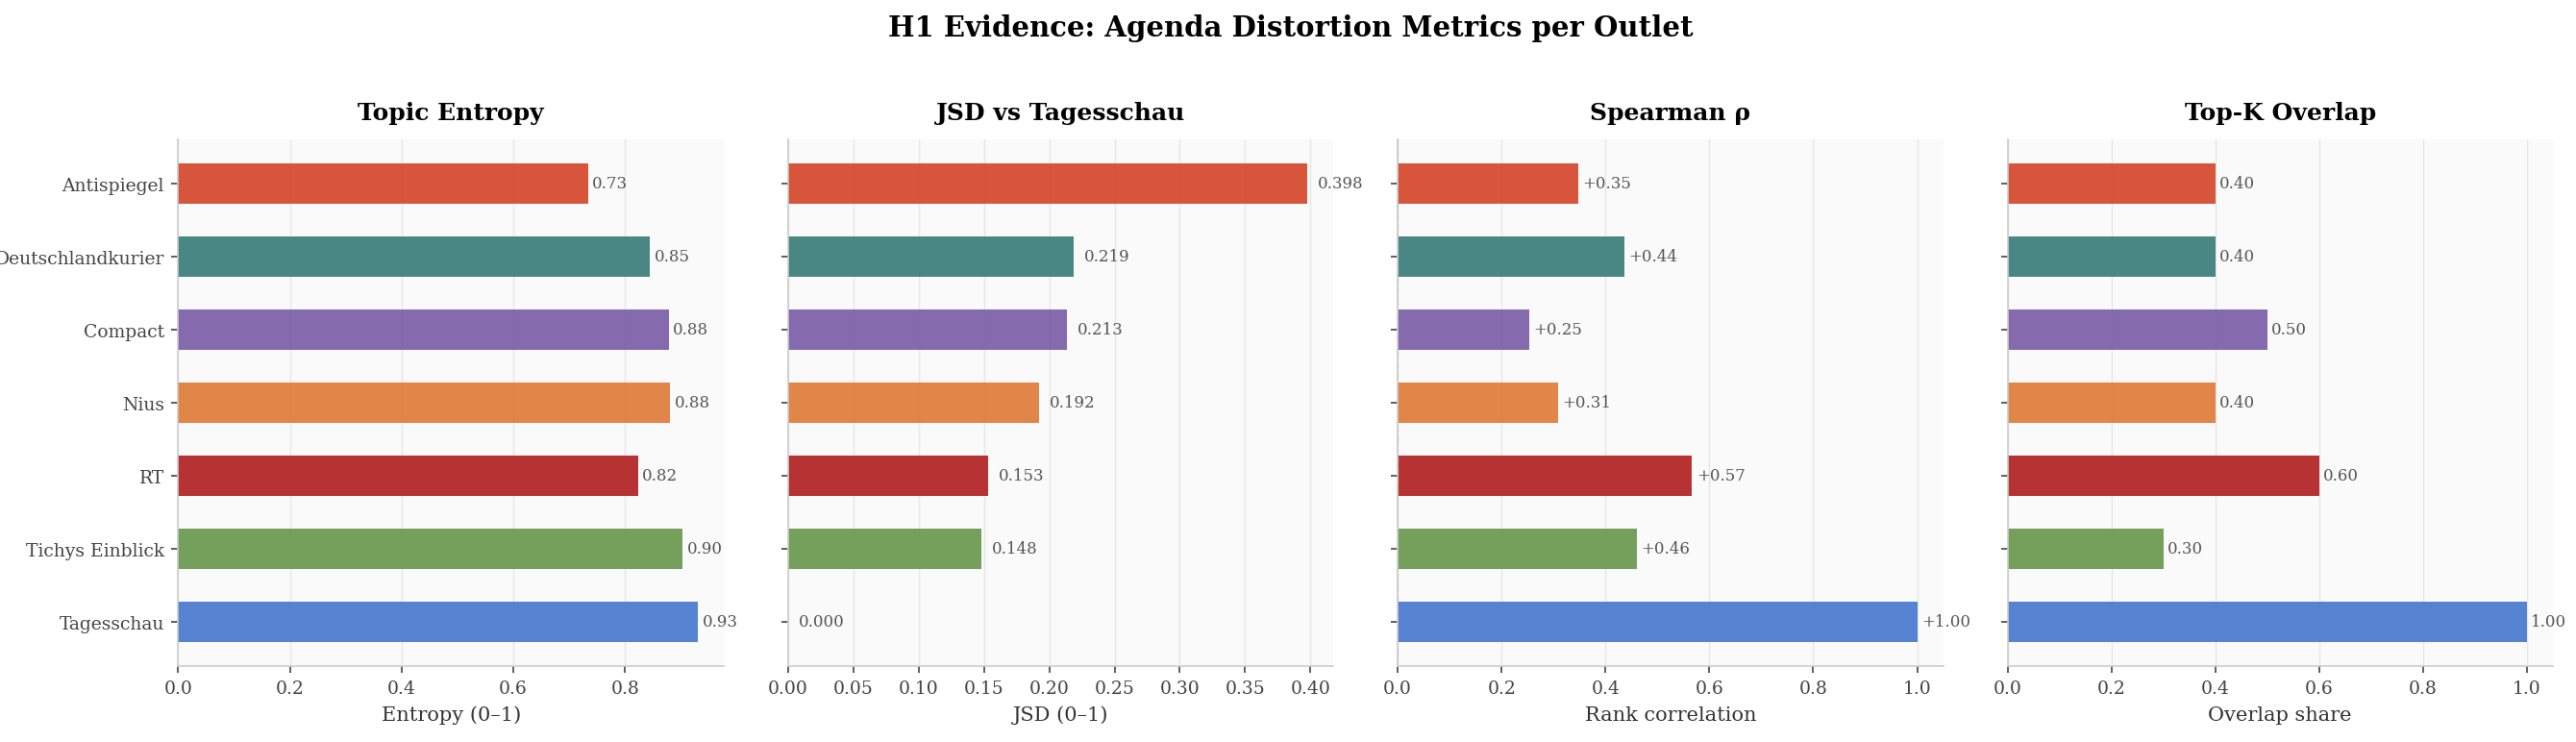

In [5]:
from visualization import plot_h1_metrics_panel, plot_coverage_breadth

fig_dir = OUTPUT_DIR / ITERATION_ID / "figures"

fig = plot_h1_metrics_panel(metrics_df, save_path=fig_dir / "h1_metrics_panel.pdf")
plt.show()

Saved: /Users/MattisHaumann/Dev/Thesis/experiments/agenda_distortion/outputs/v1/figures/h1_coverage_breadth.pdf


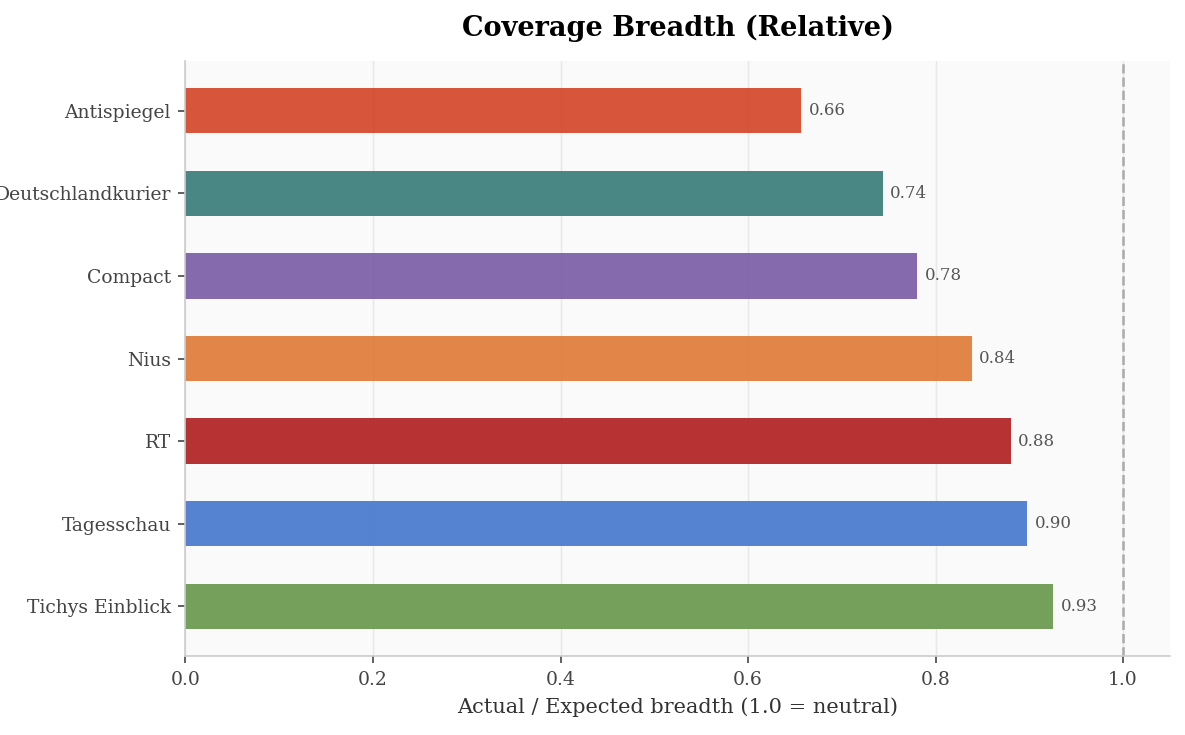

In [6]:
fig = plot_coverage_breadth(metrics_df, save_path=fig_dir / "h1_coverage_breadth.pdf")
plt.show()

Saved: /Users/MattisHaumann/Dev/Thesis/experiments/agenda_distortion/outputs/v1/figures/h1_heatmap_outlet.pdf


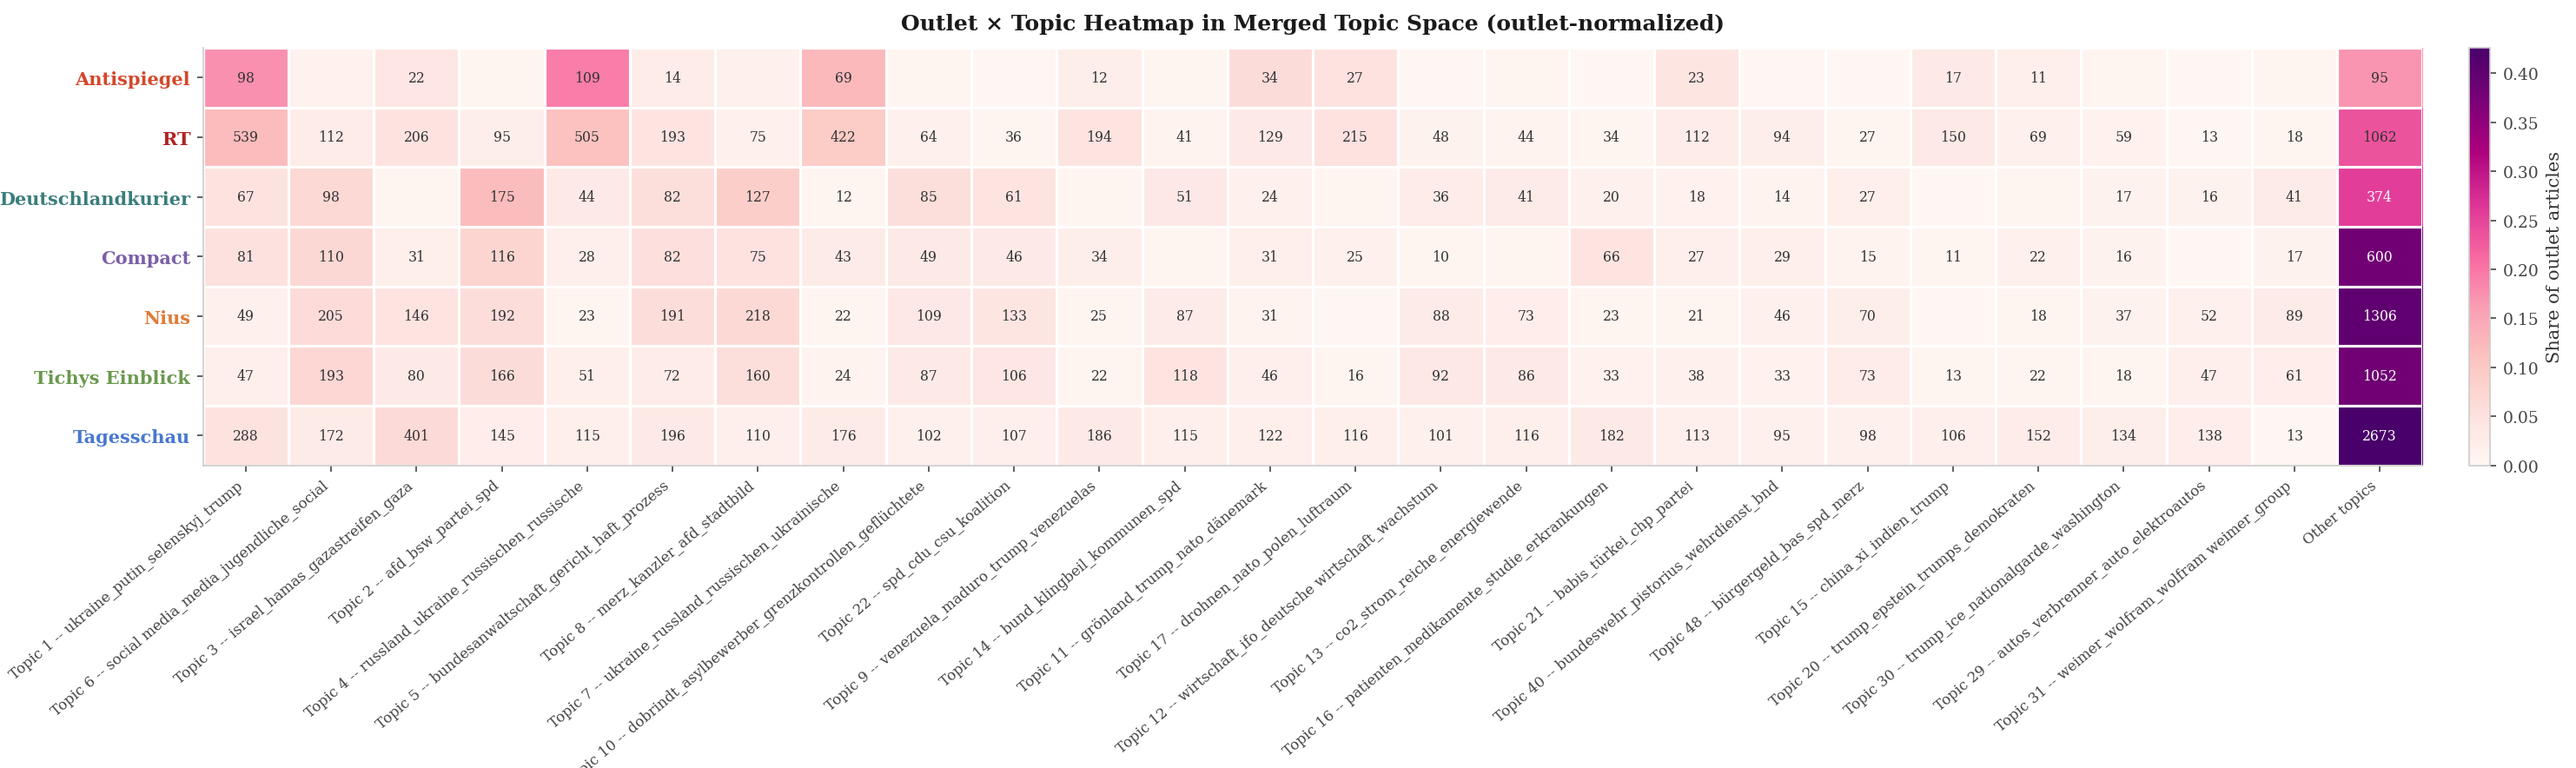

In [7]:
from visualization import plot_topic_heatmap

fig = plot_topic_heatmap(
    merged_articles, metrics_df,
    normalize="outlet",
    save_path=fig_dir / "h1_heatmap_outlet.pdf",
)
plt.show()

Saved: /Users/MattisHaumann/Dev/Thesis/experiments/agenda_distortion/outputs/v1/figures/h1_heatmap_topic.pdf


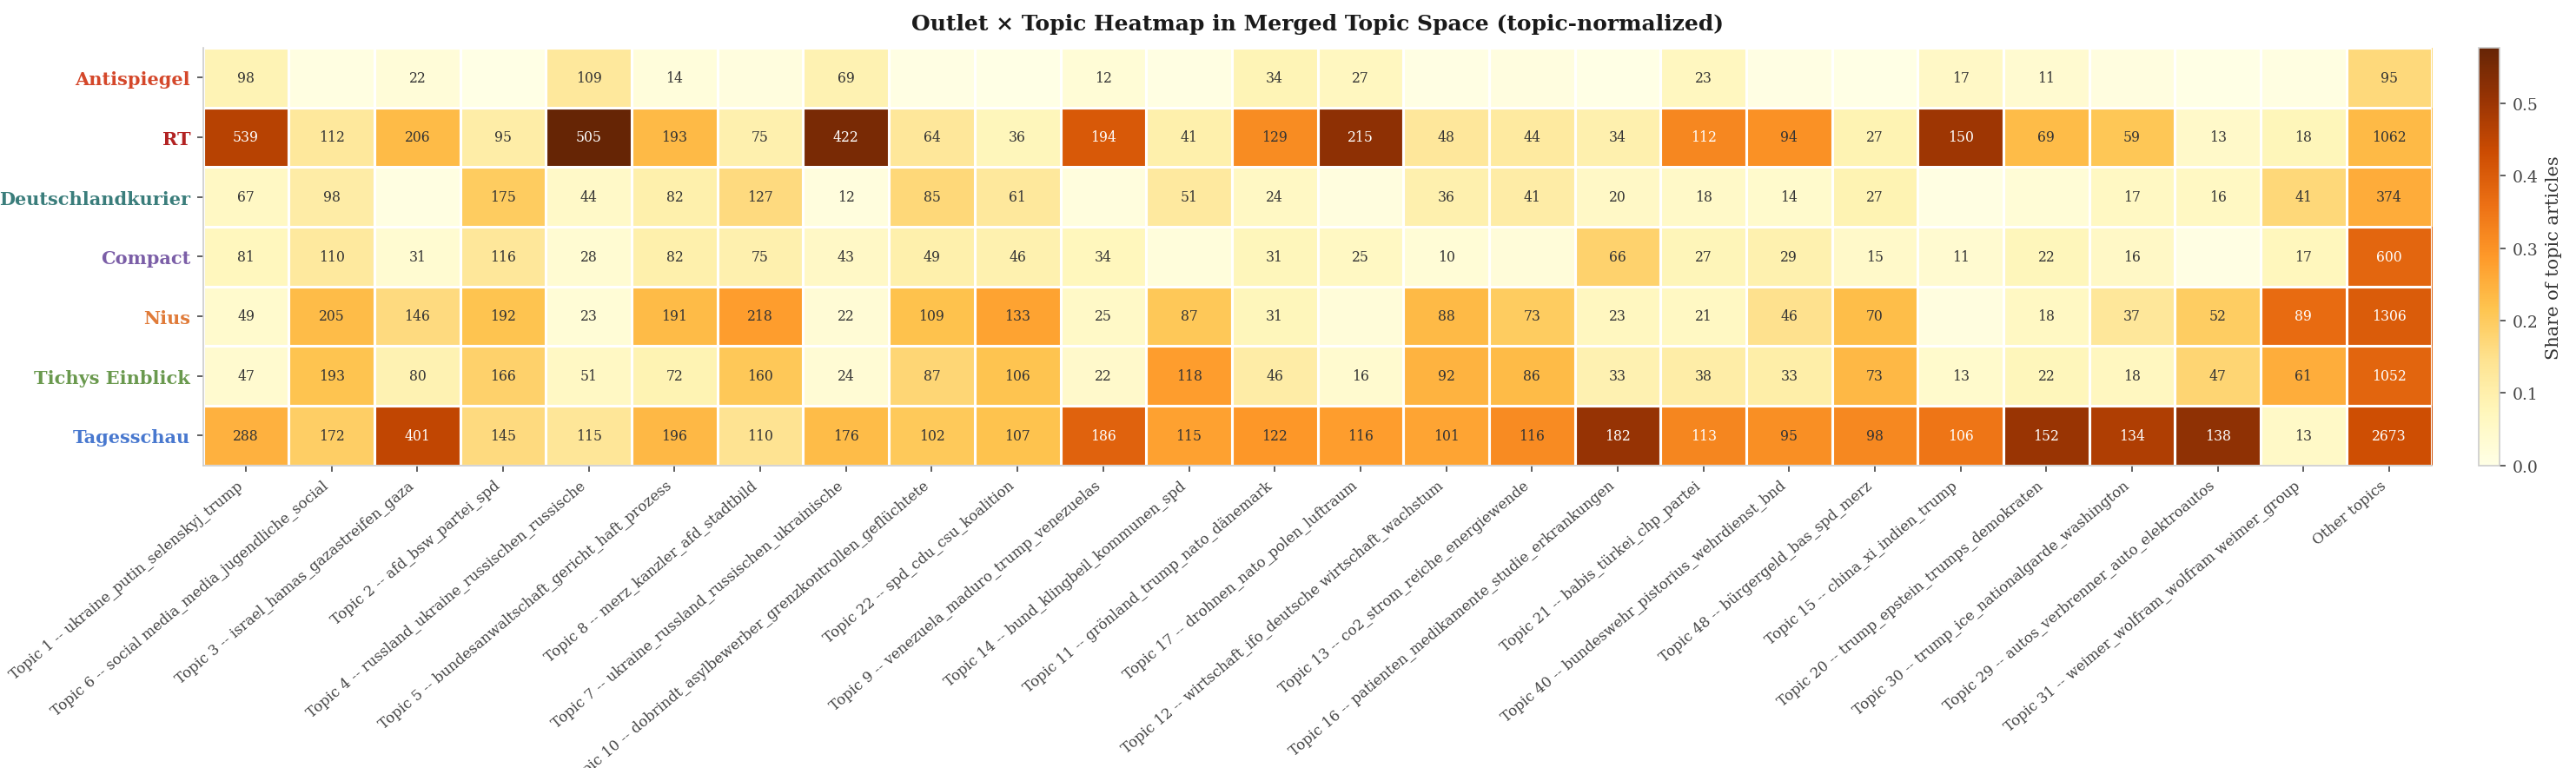

In [8]:
fig = plot_topic_heatmap(
    merged_articles, metrics_df,
    normalize="topic",
    save_path=fig_dir / "h1_heatmap_topic.pdf",
)
plt.show()

Saved: /Users/MattisHaumann/Dev/Thesis/experiments/agenda_distortion/outputs/v1/figures/h1_radar.pdf


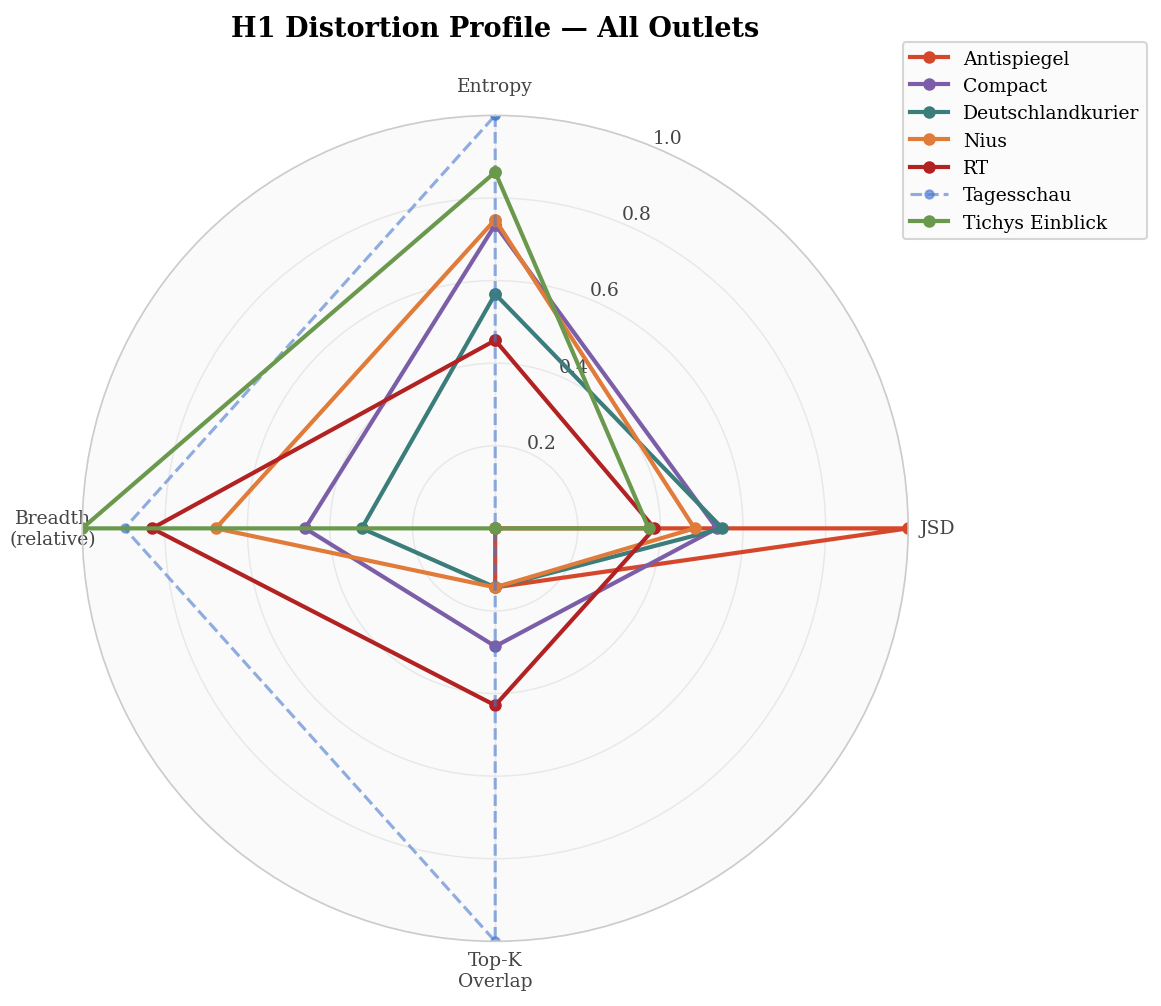

In [9]:
from visualization import plot_distortion_radar

fig = plot_distortion_radar(metrics_df, save_path=fig_dir / "h1_radar.pdf")
plt.show()

## Bootstrap Confidence Intervals

95% CIs via stratified resampling within each outlet.
CIs that exclude 0 (for JSD) or exclude 1 (for Spearman ρ) indicate statistical reliability.

In [10]:
from metrics import bootstrap_h1_metrics

print("Running bootstrap (n=1000)... this may take a few minutes.")
bootstrap_df = bootstrap_h1_metrics(merged_articles, n_bootstrap=1000)

# Display JSD CIs
print("\nJSD vs Tagesschau — Bootstrap 95% CIs")
print("=" * 70)
jsd_cis = bootstrap_df[bootstrap_df["metric"] == "jsd_vs_tagesschau"].copy()
jsd_cis = jsd_cis[jsd_cis["outlet_label"] != "Tagesschau"]
display(jsd_cis[["outlet_label", "point_estimate", "ci_lower", "ci_upper"]])

# Display Spearman CIs
print("\nSpearman ρ — Bootstrap 95% CIs")
print("=" * 70)
rho_cis = bootstrap_df[bootstrap_df["metric"] == "spearman_rho"].copy()
rho_cis = rho_cis[rho_cis["outlet_label"] != "Tagesschau"]
display(rho_cis[["outlet_label", "point_estimate", "ci_lower", "ci_upper"]])

bootstrap_df.to_csv(OUTPUT_DIR / ITERATION_ID / "h1_bootstrap.csv", index=False)

Running bootstrap (n=1000)... this may take a few minutes.

JSD vs Tagesschau — Bootstrap 95% CIs


,outlet_label,point_estimate,ci_lower,ci_upper
0,Antispiegel,0.3977,0.3885,0.4443
3,Compact,0.2134,0.2071,0.2420
6,Deutschlandkurier,0.2188,0.2116,0.2509
9,Nius,0.1920,0.1854,0.2120
12,RT,0.1534,0.1469,0.1710
18,Tichys Einblick,0.1478,0.1428,0.1674



Spearman ρ — Bootstrap 95% CIs


,outlet_label,point_estimate,ci_lower,ci_upper
1,Antispiegel,0.3468,0.2558,0.4185
4,Compact,0.2528,0.1846,0.2964
7,Deutschlandkurier,0.4371,0.3561,0.4809
10,Nius,0.3082,0.2502,0.3553
13,RT,0.5668,0.5036,0.6011
19,Tichys Einblick,0.4600,0.3859,0.4935


Saved: /Users/MattisHaumann/Dev/Thesis/experiments/agenda_distortion/outputs/v1/figures/h1_bootstrap_jsd_vs_tagesschau.pdf


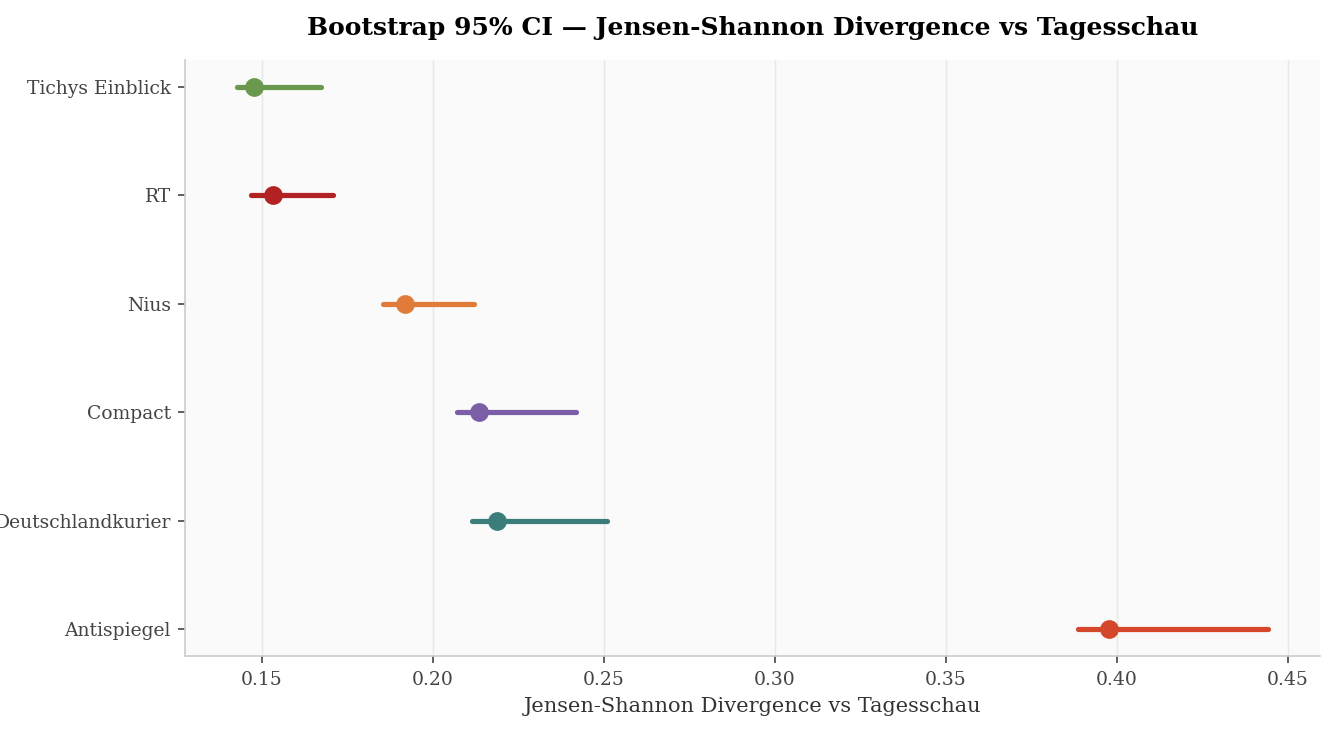

Saved: /Users/MattisHaumann/Dev/Thesis/experiments/agenda_distortion/outputs/v1/figures/h1_bootstrap_spearman_rho.pdf


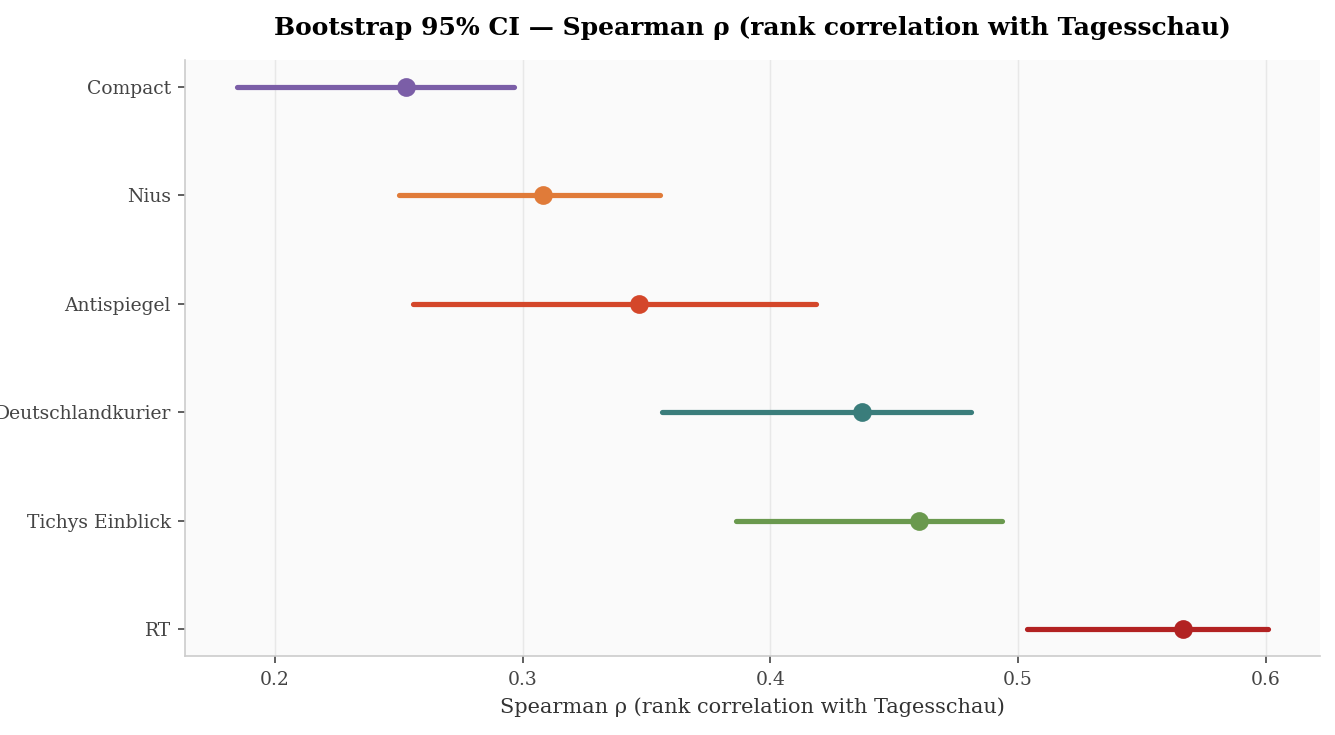

Saved: /Users/MattisHaumann/Dev/Thesis/experiments/agenda_distortion/outputs/v1/figures/h1_bootstrap_topk_overlap.pdf


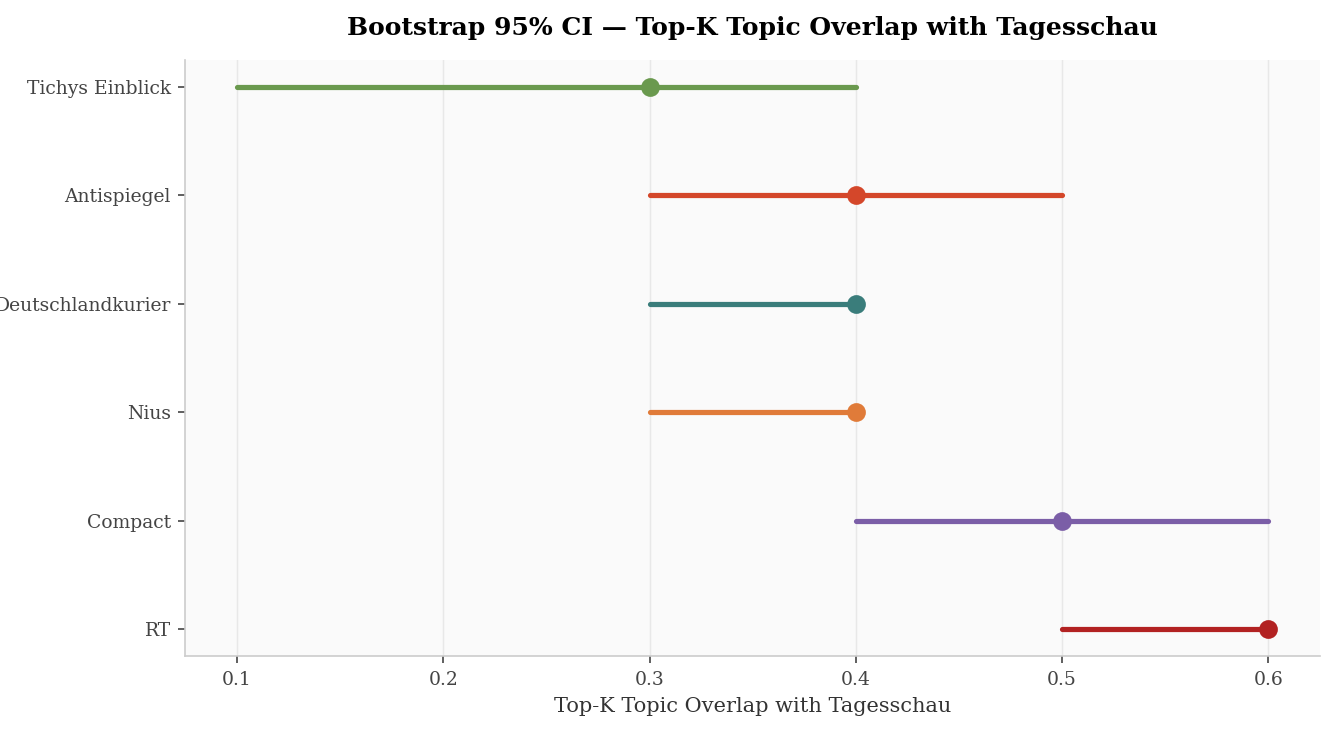

In [11]:
from visualization import plot_bootstrap_cis

for metric in ["jsd_vs_tagesschau", "spearman_rho", "topk_overlap"]:
    fig = plot_bootstrap_cis(
        bootstrap_df, metric,
        save_path=fig_dir / f"h1_bootstrap_{metric}.pdf",
    )
    plt.show()
    plt.close(fig)

## Interpretation

Fill in after running:

**Key findings:**
- Which outlets show strongest agenda distortion?
- Is distortion TYPE A (breadth), TYPE B (concentration), or both?
- Are bootstrap CIs tight enough to be confident?
- Do Spearman ρ values align with JSD (they should be inversely related)?

**Proceed to notebook 03 for robustness checks before documenting in findings.md.**